# DefectVision — Notebook 08
## Controlled 8-Epoch Ablation: Boundary Loss

Notebook 07 showed a promising 2-epoch screening result:
- Full loss: validation Dice ≈ 0.229
- No boundary loss: validation Dice ≈ 0.264
- Standard BCE + Dice: validation Dice ≈ 0.216

This notebook performs the proper controlled experiment.

Only one component changes:
- Full: weighted BCE + Dice + Boundary
- Ablation: weighted BCE + Dice

The validation set selects the winner. The test set is evaluated only after selection.


In [1]:

from pathlib import Path
import random
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

ROOT = Path.cwd().resolve().parent
DATA = ROOT / "data" / "raw" / "MVTecAD-SEG"
IMG = DATA / "imgs"
ANN = DATA / "annotations"

OUT = ROOT / "results" / "model08_ablation"
CKPT_DIR = ROOT / "models" / "checkpoints"

OUT.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 8
LR = 3e-4

print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)


Device: cpu
Epochs: 8
Batch size: 4


In [2]:
# ============================================================
# CELL 2 — FAST DATASET / DATALOADER SETUP
# ============================================================

class DefectDataset(Dataset):

    def __init__(self, split, augment=False):

        self.paths = sorted(
            (IMG / split).glob("*.png")
        )

        self.mask_dir = ANN / split
        self.augment = augment

        if len(self.paths) == 0:
            raise RuntimeError(
                f"No images found in: {IMG / split}"
            )

        self.mean = torch.tensor(
            [0.485, 0.456, 0.406]
        ).view(3, 1, 1)

        self.std = torch.tensor(
            [0.229, 0.224, 0.225]
        ).view(3, 1, 1)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        p = self.paths[idx]

        image = Image.open(
            p
        ).convert("RGB")

        mask = Image.open(
            self.mask_dir / p.name
        ).convert("L")

        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.NEAREST
        )

        image = torch.from_numpy(
            np.asarray(
                image,
                dtype=np.float32
            ) / 255.0
        ).permute(2, 0, 1).contiguous()

        mask = torch.from_numpy(
            (
                np.asarray(mask) > 0
            ).astype(np.float32)
        ).unsqueeze(0)

        if self.augment:

            if random.random() < 0.5:
                image = torch.flip(
                    image, [2]
                )
                mask = torch.flip(
                    mask, [2]
                )

            if random.random() < 0.5:
                image = torch.flip(
                    image, [1]
                )
                mask = torch.flip(
                    mask, [1]
                )

        image = (
            image - self.mean
        ) / self.std

        return image, mask, p.stem


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = DefectDataset(
    "train",
    augment=True
)

val_dataset = DefectDataset(
    "val",
    augment=False
)

test_dataset = DefectDataset(
    "test",
    augment=False
)


# ------------------------------------------------------------
# Create loaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


print("=" * 60)
print("DATASET READY")
print("=" * 60)

print("Train images :", len(train_dataset))
print("Val images   :", len(val_dataset))
print("Test images  :", len(test_dataset))

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

DATASET READY
Train images : 880
Val images   : 125
Test images  : 253
Train batches: 220
Val batches  : 32
Test batches : 64


In [3]:
# ============================================================
# CELL 3 — EXACT MODEL 06 ARCHITECTURE
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, cin, cout):

        super().__init__()

        groups = min(8, cout)

        self.c1 = nn.Conv2d(
            cin,
            cout,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.n1 = nn.GroupNorm(
            groups,
            cout
        )

        self.c2 = nn.Conv2d(
            cout,
            cout,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.n2 = nn.GroupNorm(
            groups,
            cout
        )

        self.skip = (
            nn.Conv2d(
                cin,
                cout,
                kernel_size=1,
                bias=False
            )
            if cin != cout
            else nn.Identity()
        )

        self.act = nn.ReLU(
            inplace=True
        )

    def forward(self, x):

        identity = self.skip(x)

        x = self.act(
            self.n1(
                self.c1(x)
            )
        )

        x = self.n2(
            self.c2(x)
        )

        return self.act(
            x + identity
        )


class MultiScaleBottleneck(nn.Module):

    def __init__(self, channels=64):

        super().__init__()

        branch_channels = channels // 4

        def make_branch(kernel_size, dilation):

            return nn.Sequential(

                nn.Conv2d(
                    channels,
                    branch_channels,
                    kernel_size=kernel_size,
                    padding=(
                        dilation
                        if kernel_size == 3
                        else 0
                    ),
                    dilation=dilation,
                    bias=False
                ),

                nn.GroupNorm(
                    4,
                    branch_channels
                ),

                nn.ReLU(
                    inplace=True
                )
            )

        self.b1 = make_branch(1, 1)
        self.b2 = make_branch(3, 1)
        self.b3 = make_branch(3, 2)
        self.b4 = make_branch(3, 4)

        self.fuse = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):

        branches = torch.cat(
            [
                self.b1(x),
                self.b2(x),
                self.b3(x),
                self.b4(x)
            ],
            dim=1
        )

        return self.fuse(branches) + x


class CPU_MSResidualUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.e1 = ResidualBlock(
            3,
            16
        )

        self.d1 = nn.Conv2d(
            16,
            16,
            kernel_size=3,
            stride=2,
            padding=1
        )


        self.e2 = ResidualBlock(
            16,
            32
        )

        self.d2 = nn.Conv2d(
            32,
            32,
            kernel_size=3,
            stride=2,
            padding=1
        )


        self.e3 = ResidualBlock(
            32,
            48
        )

        self.d3 = nn.Conv2d(
            48,
            48,
            kernel_size=3,
            stride=2,
            padding=1
        )


        self.e4 = ResidualBlock(
            48,
            64
        )

        self.d4 = nn.Conv2d(
            64,
            64,
            kernel_size=3,
            stride=2,
            padding=1
        )


        # -------------------------
        # Multi-scale bottleneck
        # -------------------------

        self.b = MultiScaleBottleneck(
            64
        )


        # -------------------------
        # Decoder
        # -------------------------

        self.x4 = ResidualBlock(
            128,
            48
        )

        self.x3 = ResidualBlock(
            96,
            32
        )

        self.x2 = ResidualBlock(
            64,
            16
        )

        self.x1 = ResidualBlock(
            32,
            16
        )


        # -------------------------
        # Refinement + output
        # -------------------------

        self.ref = ResidualBlock(
            16,
            8
        )

        self.out = nn.Conv2d(
            8,
            1,
            kernel_size=1
        )


    def up(self, x, target):

        return F.interpolate(
            x,
            size=target.shape[-2:],
            mode="bilinear",
            align_corners=False
        )


    def forward(self, x):

        # Encoder

        e1 = self.e1(x)

        e2 = self.e2(
            self.d1(e1)
        )

        e3 = self.e3(
            self.d2(e2)
        )

        e4 = self.e4(
            self.d3(e3)
        )


        # Bottleneck

        x = self.b(
            self.d4(e4)
        )


        # Decoder

        x = self.x4(
            torch.cat(
                [
                    self.up(x, e4),
                    e4
                ],
                dim=1
            )
        )

        x = self.x3(
            torch.cat(
                [
                    self.up(x, e3),
                    e3
                ],
                dim=1
            )
        )

        x = self.x2(
            torch.cat(
                [
                    self.up(x, e2),
                    e2
                ],
                dim=1
            )
        )

        x = self.x1(
            torch.cat(
                [
                    self.up(x, e1),
                    e1
                ],
                dim=1
            )
        )


        # Output

        return self.out(
            self.ref(x)
        )


# ============================================================
# QUICK SANITY CHECK
# ============================================================

model = CPU_MSResidualUNet()

parameter_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("MODEL 06 ARCHITECTURE READY")
print("=" * 60)

print(
    "Trainable parameters:",
    f"{parameter_count:,}"
)

print(
    "Model created successfully."
)

del model


MODEL 06 ARCHITECTURE READY
Trainable parameters: 368,169
Model created successfully.


In [4]:

class DiceLoss(nn.Module):
    def forward(self, logits, target):
        p = torch.sigmoid(logits).flatten(1)
        t = target.flatten(1)

        inter = (p * t).sum(1)

        score = (
            (2 * inter + 1)
            /
            (p.sum(1) + t.sum(1) + 1)
        )

        return 1 - score.mean()


class BoundaryLoss(nn.Module):
    def boundary(self, x):
        dilated = F.max_pool2d(x, 3, 1, 1)
        eroded = -F.max_pool2d(-x, 3, 1, 1)
        return (dilated - eroded).clamp(0, 1)

    def forward(self, logits, target):
        return F.l1_loss(
            self.boundary(torch.sigmoid(logits)),
            self.boundary(target)
        )


dice_loss = DiceLoss()
boundary_loss = BoundaryLoss()

positive_pixels = 0
total_pixels = 0

for _, masks, _ in train_loader:
    positive_pixels += masks.sum().item()
    total_pixels += masks.numel()

positive_weight = min(
    (total_pixels - positive_pixels)
    / max(positive_pixels, 1),
    20.0
)

weighted_bce = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([positive_weight])
)

print("Training defect fraction:", positive_pixels / total_pixels)
print("Positive class weight:", positive_weight)


def full_loss(logits, target):
    return (
        0.40 * weighted_bce(logits, target)
        + 0.45 * dice_loss(logits, target)
        + 0.15 * boundary_loss(logits, target)
    )


def no_boundary_loss(logits, target):
    return (
        0.50 * weighted_bce(logits, target)
        + 0.50 * dice_loss(logits, target)
    )


@torch.no_grad()
def evaluate_validation(model):
    model.eval()

    dices = []
    ious = []
    precisions = []
    recalls = []

    for images, masks, _ in val_loader:
        logits = model(images)
        pred = (torch.sigmoid(logits) >= 0.5).float()

        p = pred.flatten(1)
        t = masks.flatten(1)

        inter = (p * t).sum(1)
        pa = p.sum(1)
        ta = t.sum(1)
        union = pa + ta - inter

        fp = ((p == 1) & (t == 0)).sum(1).float()
        fn = ((p == 0) & (t == 1)).sum(1).float()

        dices.extend(
            ((2 * inter + 1e-7) /
             (pa + ta + 1e-7)).numpy()
        )
        ious.extend(
            ((inter + 1e-7) /
             (union + 1e-7)).numpy()
        )
        precisions.extend(
            ((inter + 1e-7) /
             (inter + fp + 1e-7)).numpy()
        )
        recalls.extend(
            ((inter + 1e-7) /
             (inter + fn + 1e-7)).numpy()
        )

    return {
        "dice": np.mean(dices),
        "iou": np.mean(ious),
        "precision": np.mean(precisions),
        "recall": np.mean(recalls)
    }


Training defect fraction: 0.042821103876287285
Positive class weight: 20.0


## 5. Controlled training

This is the long-running cell.

It trains:
1. `full` for 8 epochs
2. `no_boundary` for 8 epochs

Expect roughly **50–70 minutes total on your current CPU**. Progress is printed every 50 batches and after every epoch.


In [5]:

def train_variant(name, loss_fn):

    print("\n" + "=" * 70)
    print("STARTING:", name)
    print("=" * 70)

    torch.manual_seed(SEED)

    model = CPU_MSResidualUNet()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

    history = []
    best_dice = -1

    checkpoint_path = (
        CKPT_DIR /
        f"model08_{name}_best.pth"
    )

    for epoch in range(1, EPOCHS + 1):

        start = time.time()
        model.train()
        running_loss = 0.0

        for batch_idx, (images, masks, _) in enumerate(
            train_loader, start=1
        ):

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = loss_fn(logits, masks)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            if (
                batch_idx == 1
                or batch_idx % 50 == 0
                or batch_idx == len(train_loader)
            ):
                print(
                    f"{name} | "
                    f"epoch {epoch}/{EPOCHS} | "
                    f"batch {batch_idx}/{len(train_loader)} | "
                    f"loss {loss.item():.4f}",
                    flush=True
                )

        train_loss = (
            running_loss /
            len(train_loader.dataset)
        )

        val = evaluate_validation(model)

        scheduler.step(val["dice"])

        elapsed = time.time() - start

        history.append({
            "variant": name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_dice": val["dice"],
            "val_iou": val["iou"],
            "val_precision": val["precision"],
            "val_recall": val["recall"],
            "lr": optimizer.param_groups[0]["lr"],
            "seconds": elapsed
        })

        print(
            f"{name} | EPOCH {epoch} COMPLETE | "
            f"train {train_loss:.4f} | "
            f"Dice {val['dice']:.4f} | "
            f"IoU {val['iou']:.4f} | "
            f"Precision {val['precision']:.4f} | "
            f"Recall {val['recall']:.4f} | "
            f"{elapsed/60:.2f} min",
            flush=True
        )

        if val["dice"] > best_dice:

            best_dice = val["dice"]

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "val_dice": val["dice"],
                    "val_iou": val["iou"],
                    "val_precision": val["precision"],
                    "val_recall": val["recall"]
                },
                checkpoint_path
            )

            print(
                ">>> Best checkpoint saved",
                flush=True
            )

    return pd.DataFrame(history), checkpoint_path


full_history, full_checkpoint = train_variant(
    "full",
    full_loss
)

no_boundary_history, no_boundary_checkpoint = train_variant(
    "no_boundary",
    no_boundary_loss
)

history = pd.concat(
    [full_history, no_boundary_history],
    ignore_index=True
)

history.to_csv(
    OUT / "controlled_ablation_history.csv",
    index=False
)

print("\nCONTROLLED ABLATION TRAINING COMPLETE")



STARTING: full
full | epoch 1/8 | batch 1/220 | loss 0.8268
full | epoch 1/8 | batch 50/220 | loss 1.1842
full | epoch 1/8 | batch 100/220 | loss 1.3999
full | epoch 1/8 | batch 150/220 | loss 0.6256
full | epoch 1/8 | batch 200/220 | loss 0.5897
full | epoch 1/8 | batch 220/220 | loss 1.8830
full | EPOCH 1 COMPLETE | train 0.8187 | Dice 0.2131 | IoU 0.1460 | Precision 0.1643 | Recall 0.7357 | 10.19 min
>>> Best checkpoint saved
full | epoch 2/8 | batch 1/220 | loss 0.6441
full | epoch 2/8 | batch 50/220 | loss 0.6668
full | epoch 2/8 | batch 100/220 | loss 0.5364
full | epoch 2/8 | batch 150/220 | loss 0.7341
full | epoch 2/8 | batch 200/220 | loss 1.2385
full | epoch 2/8 | batch 220/220 | loss 0.5522
full | EPOCH 2 COMPLETE | train 0.7650 | Dice 0.2849 | IoU 0.2090 | Precision 0.2363 | Recall 0.7312 | 10.05 min
>>> Best checkpoint saved
full | epoch 3/8 | batch 1/220 | loss 0.7636
full | epoch 3/8 | batch 50/220 | loss 0.4618
full | epoch 3/8 | batch 100/220 | loss 0.7691
full | epo

CONTROLLED ABLATION — VALIDATION RESULTS


,variant,best_epoch,best_val_dice,best_val_iou,precision,recall
0,full,7,0.4237,0.3197,0.3989,0.6927
1,no_boundary,8,0.4270,0.3178,0.4055,0.7074



VALIDATION-SELECTED WINNER: no_boundary
Winner validation Dice: 0.4270
Winner validation IoU: 0.3178
Best epoch: 8
Checkpoint: C:\Documents\DefectVision\models\checkpoints\model08_no_boundary_best.pth

Validation Dice difference: 0.0033


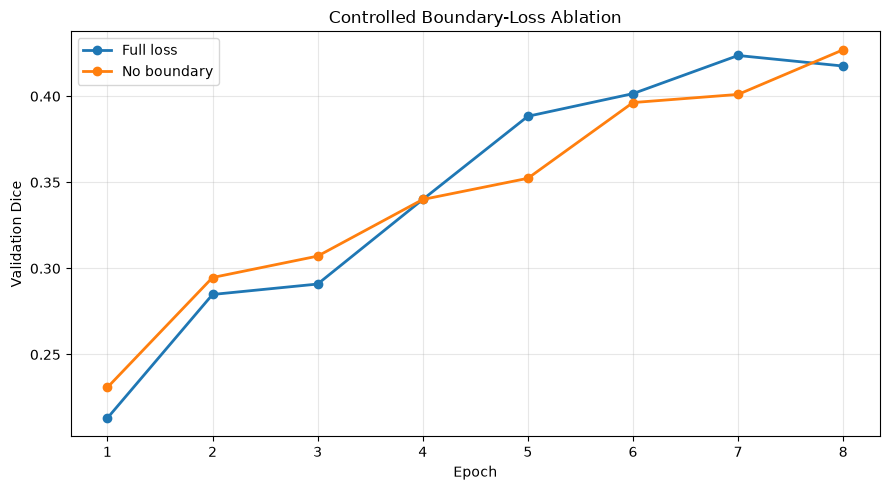


CELL 6 COMPLETE
Selected variant: no_boundary
Test evaluation has NOT been performed yet.
Next step: evaluate the selected checkpoint ONCE on the held-out test set.


In [8]:
# ============================================================
# CELL 6 — VALIDATION COMPARISON + WINNER SELECTION
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Collect best validation result for each variant
# ------------------------------------------------------------

summary_rows = []

for name, hist in [
    ("full", full_history),
    ("no_boundary", no_boundary_history)
]:

    best = hist.loc[
        hist["val_dice"].idxmax()
    ]

    summary_rows.append({

        "variant": name,

        "best_epoch":
            int(best["epoch"]),

        "best_val_dice":
            float(best["val_dice"]),

        "best_val_iou":
            float(best["val_iou"]),

        "precision":
            float(best["val_precision"]),

        "recall":
            float(best["val_recall"])
    })


summary = pd.DataFrame(
    summary_rows
)


# ------------------------------------------------------------
# 2. Display validation comparison
# ------------------------------------------------------------

print("=" * 70)
print("CONTROLLED ABLATION — VALIDATION RESULTS")
print("=" * 70)

display(
    summary.style.format({

        "best_val_dice":
            "{:.4f}",

        "best_val_iou":
            "{:.4f}",

        "precision":
            "{:.4f}",

        "recall":
            "{:.4f}"
    })
)


# ------------------------------------------------------------
# 3. Save summary
# ------------------------------------------------------------

summary.to_csv(
    OUT / "controlled_ablation_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Select winner ONLY using validation Dice
# ------------------------------------------------------------

winner_index = summary[
    "best_val_dice"
].idxmax()

winner = summary.loc[
    winner_index,
    "variant"
]


if winner == "full":

    winner_checkpoint = (
        full_checkpoint
    )

else:

    winner_checkpoint = (
        no_boundary_checkpoint
    )


print()
print("=" * 70)
print(
    "VALIDATION-SELECTED WINNER:",
    winner
)
print("=" * 70)

print(
    "Winner validation Dice:",
    f"{summary.loc[winner_index, 'best_val_dice']:.4f}"
)

print(
    "Winner validation IoU:",
    f"{summary.loc[winner_index, 'best_val_iou']:.4f}"
)

print(
    "Best epoch:",
    summary.loc[winner_index, "best_epoch"]
)

print(
    "Checkpoint:",
    winner_checkpoint
)


# ------------------------------------------------------------
# 5. Calculate improvement over the other variant
# ------------------------------------------------------------

if len(summary) == 2:

    dice_values = summary[
        "best_val_dice"
    ].values

    dice_difference = (
        abs(dice_values[0] - dice_values[1])
    )

    print()
    print(
        "Validation Dice difference:",
        f"{dice_difference:.4f}"
    )


# ------------------------------------------------------------
# 6. Plot validation Dice curves
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)


ax.plot(
    full_history["epoch"],
    full_history["val_dice"],
    marker="o",
    linewidth=2,
    label="Full loss"
)


ax.plot(
    no_boundary_history["epoch"],
    no_boundary_history["val_dice"],
    marker="o",
    linewidth=2,
    label="No boundary"
)


ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Validation Dice"
)

ax.set_title(
    "Controlled Boundary-Loss Ablation"
)

ax.set_xticks(
    range(
        1,
        EPOCHS + 1
    )
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()


plt.tight_layout()


plot_path = (
    OUT /
    "controlled_ablation_dice.png"
)

plt.savefig(
    plot_path,
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. Save complete training history
# ------------------------------------------------------------

history = pd.concat(
    [
        full_history,
        no_boundary_history
    ],
    ignore_index=True
)

history.to_csv(
    OUT /
    "controlled_ablation_history.csv",
    index=False
)


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print()
print("=" * 70)
print("CELL 6 COMPLETE")
print("=" * 70)

print(
    "Selected variant:",
    winner
)

print(
    "Test evaluation has NOT been performed yet."
)

print(
    "Next step: evaluate the selected checkpoint ONCE "
    "on the held-out test set."
)

## 7. Final held-out test evaluation

Only now is the test set used.

The winner was selected strictly using validation Dice.


In [9]:

@torch.no_grad()
def evaluate_test(model):

    model.eval()

    dices = []
    ious = []
    precisions = []
    recalls = []

    for images, masks, _ in test_loader:

        logits = model(images)
        pred = (torch.sigmoid(logits) >= 0.5).float()

        p = pred.flatten(1)
        t = masks.flatten(1)

        inter = (p * t).sum(1)
        pa = p.sum(1)
        ta = t.sum(1)
        union = pa + ta - inter

        fp = ((p == 1) & (t == 0)).sum(1).float()
        fn = ((p == 0) & (t == 1)).sum(1).float()

        dices.extend(
            ((2 * inter + 1e-7) /
             (pa + ta + 1e-7)).numpy()
        )

        ious.extend(
            ((inter + 1e-7) /
             (union + 1e-7)).numpy()
        )

        precisions.extend(
            ((inter + 1e-7) /
             (inter + fp + 1e-7)).numpy()
        )

        recalls.extend(
            ((inter + 1e-7) /
             (inter + fn + 1e-7)).numpy()
        )

    return {
        "Dice": np.mean(dices),
        "IoU": np.mean(ious),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls)
    }


checkpoint = torch.load(
    winner_checkpoint,
    map_location=DEVICE,
    weights_only=False
)

final_model = CPU_MSResidualUNet()

final_model.load_state_dict(
    checkpoint["model_state_dict"]
)

final_model.eval()

final_test = evaluate_test(final_model)

print("=" * 65)
print("FINAL VALIDATION-SELECTED MODEL — TEST")
print("=" * 65)

print("Selected variant:", winner)
print("Best validation epoch:", checkpoint["epoch"])

for key, value in final_test.items():
    print(f"{key}: {value:.6f}")


comparison = pd.DataFrame([
    {
        "model": "Notebook 04 baseline",
        "Dice": 0.206994,
        "IoU": 0.143440,
        "Precision": 0.313602,
        "Recall": 0.539982
    },
    {
        "model": "Notebook 06",
        "Dice": 0.353307,
        "IoU": 0.252814,
        "Precision": 0.325253,
        "Recall": 0.682221
    },
    {
        "model": f"Notebook 08 selected ({winner})",
        "Dice": final_test["Dice"],
        "IoU": final_test["IoU"],
        "Precision": final_test["Precision"],
        "Recall": final_test["Recall"]
    }
])

display(comparison)

comparison.to_csv(
    OUT / "final_model_comparison.csv",
    index=False
)


FINAL VALIDATION-SELECTED MODEL — TEST
Selected variant: no_boundary
Best validation epoch: 8
Dice: 0.375300
IoU: 0.275828
Precision: 0.348382
Recall: 0.698829


,model,Dice,IoU,Precision,Recall
0,Notebook 04 baseline,0.206994,0.143440,0.313602,0.539982
1,Notebook 06,0.353307,0.252814,0.325253,0.682221
2,Notebook 08 selected (no_boundary),0.375300,0.275828,0.348382,0.698829


## Final interpretation

Do not choose the final loss from the test score.

The correct decision is:

**highest validation Dice → final model → one held-out test evaluation.**

If `no_boundary` wins validation and maintains or improves the held-out test result, we have evidence that the boundary term was unnecessary.

If `full` wins, retain the original Model 06 loss.

Either result is valuable because the project now contains a controlled ablation rather than an unsupported architectural choice.
